<a href="https://colab.research.google.com/github/Ariyan-Sk/AI-fruit-classifier/blob/main/notebook1f19295e14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
muhammad0subhan_fruit_and_vegetable_disease_healthy_vs_rotten_path = kagglehub.dataset_download('muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten')

print('Data source import complete.')


100%|██████████| 4.77G/4.77G [01:05<00:00, 78.3MB/s]

Extracting files...


Data source import complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [ ]:
print(os.listdir(muhammad0subhan_fruit_and_vegetable_disease_healthy_vs_rotten_path))

['Fruit And Vegetable Diseases Dataset']


In [ ]:
data_dir = os.path.join(
    muhammad0subhan_fruit_and_vegetable_disease_healthy_vs_rotten_path,
    "Fruit And Vegetable Diseases Dataset"
)

img_height = 128
img_width = 128
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 29277 files belonging to 28 classes.
Using 23422 files for training.
Found 29277 files belonging to 28 classes.
Using 5855 files for validation.


In [ ]:
test_ds = val_ds
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['Apple__Healthy', 'Apple__Rotten', 'Banana__Healthy', 'Banana__Rotten', 'Bellpepper__Healthy', 'Bellpepper__Rotten', 'Carrot__Healthy', 'Carrot__Rotten', 'Cucumber__Healthy', 'Cucumber__Rotten', 'Grape__Healthy', 'Grape__Rotten', 'Guava__Healthy', 'Guava__Rotten', 'Jujube__Healthy', 'Jujube__Rotten', 'Mango__Healthy', 'Mango__Rotten', 'Orange__Healthy', 'Orange__Rotten', 'Pomegranate__Healthy', 'Pomegranate__Rotten', 'Potato__Healthy', 'Potato__Rotten', 'Strawberry__Healthy', 'Strawberry__Rotten', 'Tomato__Healthy', 'Tomato__Rotten']


In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names),
                 activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 1027s 1s/step - accuracy: 0.4266 - loss: 1.9442 - val_accuracy: 0.6676 - val_loss: 1.1027
Epoch 2/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 860s 1s/step - accuracy: 0.6318 - loss: 1.2073 - val_accuracy: 0.7339 - val_loss: 0.8631
Epoch 3/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 859s 1s/step - accuracy: 0.7051 - loss: 0.9524 - val_accuracy: 0.8102 - val_loss: 0.6394
Epoch 4/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 844s 1s/step - accuracy: 0.7496 - loss: 0.7861 - val_accuracy: 0.8041 - val_loss: 0.6436
Epoch 5/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 851s 1s/step - accuracy: 0.7905 - loss: 0.6544 - val_accuracy: 0.8427 - val_loss: 0.5309
Epoch 6/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 856s 1s/step - accuracy: 0.8162 - loss: 0.5648 - val_accuracy: 0.8683 - val_loss: 0.4470
Epoch 7/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 845s 1s/step - accuracy: 0.8375 - loss: 0.4918 - val_accuracy: 0.8719 - val_loss: 0.4623
Epoch 8/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 828s 1s/step - accuracy: 0.8575 - loss: 0.4277 - val_acc

In [12]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy =", accuracy)

183/183 ━━━━━━━━━━━━━━━━━━━━ 57s 309ms/step - accuracy: 0.8907 - loss: 0.4791
Validation Accuracy = 0.8906916975975037


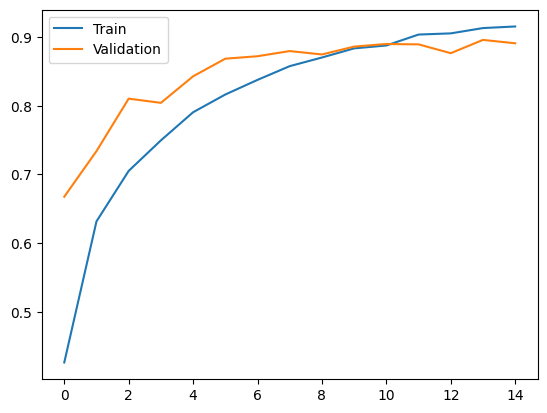

In [13]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.show()

In [14]:
#Testing

sample_path = os.path.join(
    data_dir,
    "Carrot__Healthy",   # any class folder
    os.listdir(os.path.join(data_dir, "Carrot__Healthy"))[0]
)

print(sample_path)

/root/.cache/kagglehub/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten/versions/1/Fruit And Vegetable Diseases Dataset/Carrot__Healthy/freshCarrot (135).jpg


In [15]:
img = tf.keras.utils.load_img(
    sample_path,
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) / 255

pred = model.predict(img_array)
score = pred[0]

print("Predicted Class:",
      class_names[tf.argmax(score)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
Predicted Class: Carrot__Healthy


In [26]:
from google.colab import files
uploaded = files.upload()

Saving istockphoto-925300156-612x612.jpg to istockphoto-925300156-612x612 (3).jpg


In [27]:
img_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(
    img_path,
    target_size=(128,128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
img_array = img_array / 255.0

pred = model.predict(img_array)
score = pred[0]

predicted_class = class_names[tf.argmax(score)]
confidence = 100 * tf.reduce_max(score)

print(f"Prediction: {predicted_class} ({confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: Carrot__Rotten (99.48%)
